<div style='text-align: center; padding: 30px'>
  <h1><strong>Plotting the Efficient Frontier</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns, plotting

In [34]:
file = r'cryptos-index.csv'
data_index = pd.read_csv(file, index_col="Date", parse_dates=True)

In [35]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [36]:
mu = expected_returns.mean_historical_return(data, frequency=31)
s = risk_models.sample_cov(data, frequency=31)

# **MAX SHARPE BUY ONLY**

In [37]:
efbuy = EfficientFrontier(mu, s)    # Efficient Frontier Buy

In [38]:
efbuycopy = efbuy.deepcopy()

In [39]:
efbuyms = efbuy.max_sharpe()        # Efficient Frontier Buy Max Sharpe

In [40]:
wefbuy = efbuy.clean_weights()      # Weights Efficient Frontier Buy

# **MAX SHARPE CFDs**

In [41]:
efcfd = EfficientFrontier(mu, s, weight_bounds=(-1, 1))    # Efficient Frontier Buy

In [42]:
efcfdcopy = efcfd.deepcopy()        # a copy for not calculating again

In [43]:
efcfdms = efcfd.max_sharpe()        # Efficient Frontier Buy Max Sharpe

In [44]:
wefcfd = efcfd.clean_weights()      # Weights Efficient Frontier Buy

# **EFFICIENT FRONTIER PLOT**

In [45]:
efcfd = efcfdcopy.deepcopy()
efbuy = efbuycopy.deepcopy()

In [46]:
ewr = data_index['EWP'].pct_change().dropna()   # Equal Weighted Portfolio Returns
ppr = data_index['PP' ].pct_change().dropna()   # Ponderated Portfolio Returns

In [47]:
ewrm = ewr.mean()  # Equal Weighted Portfolio Mean
pprm = ppr.mean()  # Ponderated Portfolio Mean

ewrs = ewr.std()   # Equal Weighted Portfolio Standard Deviation
pprs = ppr.std()   # Ponderated Portfolio Standard Deviation


# make them mensual
ewrm = (1 + ewrm) ** ( 30/len(ewr) ) - 1
pprm = (1 + pprm) ** ( 30/len(ppr) ) - 1

ewrs = ewrs * np.sqrt(30)
pprs = pprs * np.sqrt(30)


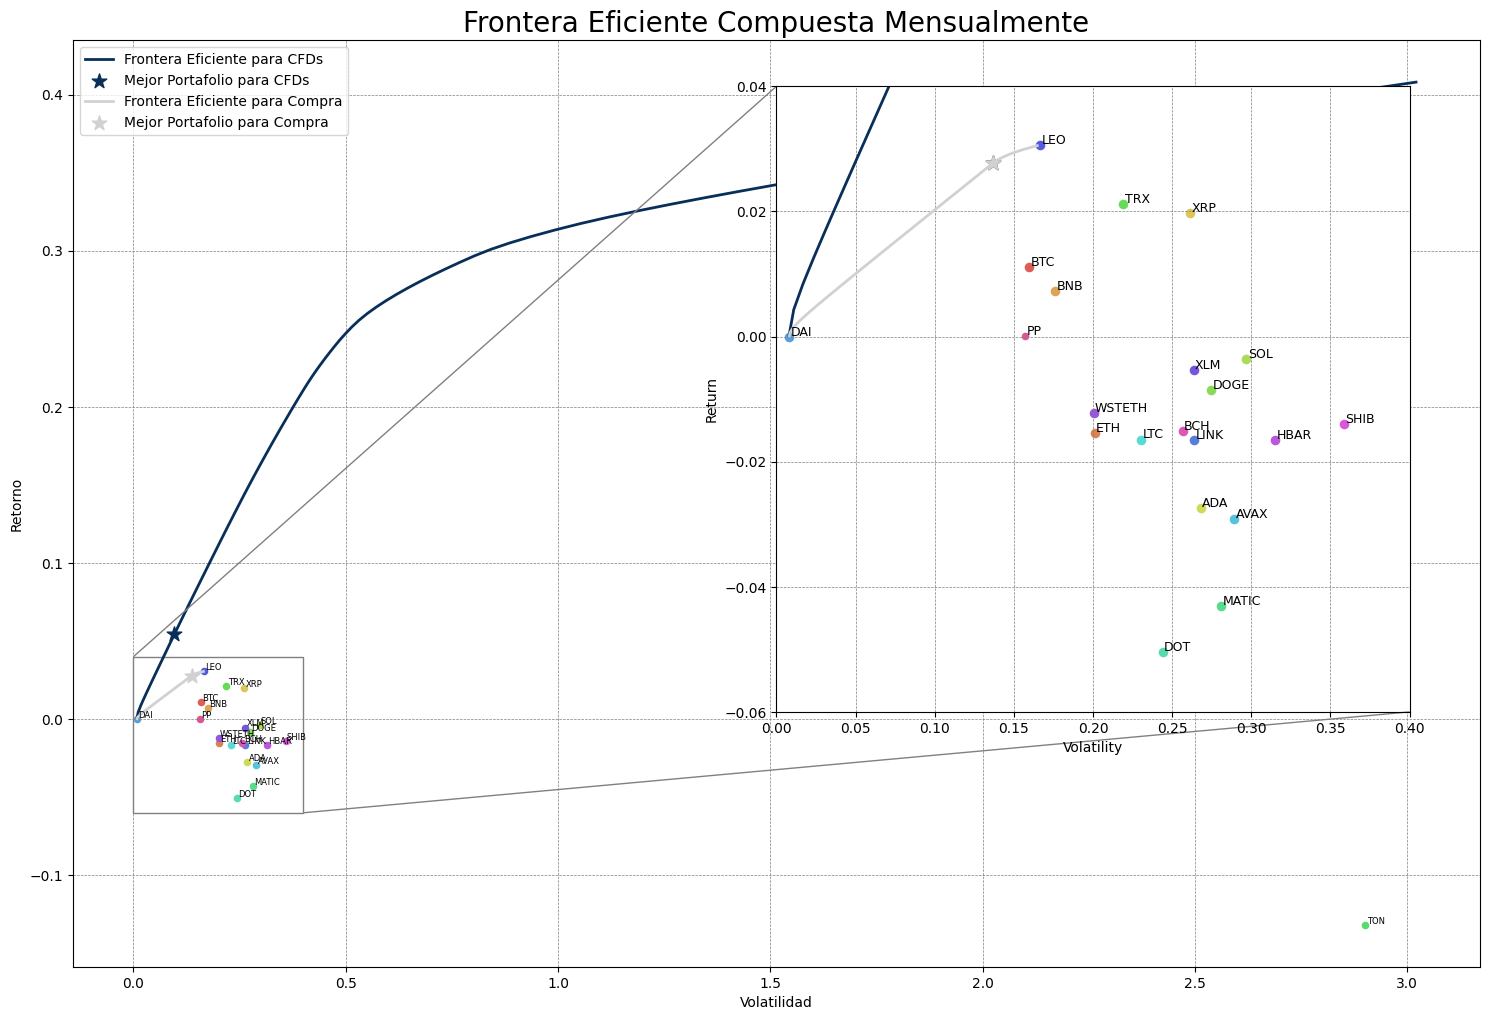

In [51]:
# Set the color palette
palette = sns.color_palette("hls", len(data_index.columns))



# ------------------- Efficient Frontier for CFDs -------------------

# Plot the efficient frontier
fig, ax = plt.subplots(figsize=(15, 10))                                # Create a figure and a set of subplots
efcfdms = efcfd.deepcopy()                                              # Efficietn Frontier CFD Max Sharpe
efcfdpl = efcfd.deepcopy()                                              # Efficient Frontier CFD Plot
plotting.plot_efficient_frontier(efcfdpl, ax=ax, show_assets=False)     # Plot the efficient frontier (without the individual assets for now)


# Change the line of the efficient frontier
for line in ax.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#082f5a')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")


# find the tangency portfolio and plot it
efcfdms.max_sharpe()
ret_tangent, std_tangent, _ = efcfdms.portfolio_performance()
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#082f5a", label="Mejor Portafolio para CFDs")



# ------------------- Efficient Frontier for Only Buy -------------------

# Plot the efficient frontier
efbuyms = efbuy.deepcopy()                                              # Efficient Frontier Buy Max Sharpe
eybuypl = efbuy.deepcopy()                                              # Efficient Frontier Buy Plot
plotting.plot_efficient_frontier(eybuypl, ax=ax, show_assets=False)     # Plot the efficient frontier (without the individual assets for now) 


# Change the line of the efficient frontier
for line in ax.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#d1d1d1')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para Compra")

# find the tangency portfolio and plot it
efbuyms.max_sharpe()
ret_tangent, std_tangent, _ = efbuyms.portfolio_performance()
ax.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#d1d1d1", label="Mejor Portafolio para Compra")



# ------------------- Individual Assets -------------------

# Annotate each asset with its volatility (x) and expected return (y)
asset_volatilities = np.sqrt(np.diag(s))
asset_returns = np.array(mu)

for i, txt in enumerate(data.columns):
    ax.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(1, 1), textcoords='offset points', fontsize=6)
    ax.scatter(asset_volatilities[i], asset_returns[i], marker='o', color=palette[i], s=20)

# add the equal weighted portfolio to the plot
# ax.scatter(ewrs, ewrm, marker="o", s=20, color=palette[-1])
ax.scatter(pprs, pprm, marker="o", s=20, color=palette[-2])

# add text for the equal weighted portfolio
# ax.annotate('EWP', (ewrs, ewrm), xytext=(1, 1), textcoords='offset points', fontsize=6)
ax.annotate('PP', (pprs, pprm), xytext=(1, 1), textcoords='offset points', fontsize=6)


# ------------------- Inset with zoomed region -------------------

# Create inset of the zoomed region

x_zoom = (0, .4)
y_zoom = (-0.06, 0.04)

width = 0.3*1.5
height = 0.45*1.5

axins = ax.inset_axes([.95 - width, .95 - height, width, height]) # x, y, width, height
axins.set_xlim(x_zoom)
axins.set_ylim(y_zoom)

# Plot the same data on the inset
for i, txt in enumerate(data.columns):
    axins.annotate(txt, (asset_volatilities[i], asset_returns[i]), xytext=(1, 1), textcoords='offset points', fontsize=9)
    axins.scatter(asset_volatilities[i], asset_returns[i], marker='o', s=35, color=palette[i])

# add the equal weighted portfolio to the plot
# axins.scatter(ewrs, ewrm, marker="o", s=20, color=palette[-1])
axins.scatter(pprs, pprm, marker="o", s=20, color=palette[-2])

# add text for the equal weighted portfolio
# axins.annotate('EWP', (ewrs, ewrm), xytext=(1, 1), textcoords='offset points', fontsize=6)
axins.annotate('PP', (pprs, pprm), xytext=(1, 1), textcoords='offset points', fontsize=9)


# plot the efficient frontier
efcfdpl2 = efcfd.deepcopy()

plotting.plot_efficient_frontier(efcfdpl2, ax=axins, show_assets=False, showfig=False)

for line in axins.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#082f5a')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")

axins.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#082f5a")


efbuypl2 = efbuy.deepcopy()
plotting.plot_efficient_frontier(efbuypl2, ax=axins, show_assets=False, showfig=False)
for line in axins.get_lines():
    if line.get_label() == 'Efficient frontier':
        line.set_color('#d1d1d1')
        line.set_linewidth(2)
        line.set_label("Frontera Eficiente para CFDs")
axins.scatter(std_tangent, ret_tangent, marker="*", s=120, c="#d1d1d1")

# add grid
axins.grid(True, color='gray', linestyle='--', linewidth=0.5)
axins.get_legend().remove()

# Mark the zoomed area on the main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")



# ------------------- Final adjustments -------------------

# Add new legend with updated labels
handles, labels = ax.get_legend_handles_labels()
new_labels = ['Cryptos' if label == 'assets' else label for label in labels]
ax.legend(handles, new_labels)
ax.set_facecolor('white')

ax.grid(True, color='gray', linestyle='--', linewidth=0.5)
# ax.set_xticks(np.arange(0, int(ax.get_xlim()[1]) + 1, 1))


# Plot the efficient frontier
plt.tight_layout()
plt.title('Frontera Eficiente Compuesta Mensualmente', fontsize=20, color='black')
ax.set_xlabel('Volatilidad')
ax.set_ylabel('Retorno')
plt.savefig("svg/04-efficient_frontier-1m.svg", format="svg", bbox_inches='tight')
plt.show()